<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/homework7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16 Homework: Convolutional Neural Networks
- **Exercise 16.1:** Modify the chapter's convnet (Section 16.6) to use Fashion-MNIST instead of MNIST, and compare accuracy and training time.
- **Exercise 16.4:** Remove the first Dense layer, then add a Dense layer with 4096 neurons, and compare prediction accuracy and speed.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

keras.utils.set_random_seed(42)  # for more reproducible results

# GPU warm-up: the first model on a GPU is slower because of start-up costs.
# This small run makes the later timing comparisons fair.
warmup = keras.Sequential([keras.Input(shape=(28, 28, 1)),
                           keras.layers.Conv2D(8, (3, 3)),
                           keras.layers.Flatten(),
                           keras.layers.Dense(10)])
warmup.compile(optimizer="adam", loss="mse")
warmup.fit(np.random.rand(256, 28, 28, 1), np.random.rand(256, 10), epochs=1, verbose=0)
print("GPU warm-up done")

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU warm-up done


## Exercise 16.1: Fashion-MNIST
### Loading the Fashion-MNIST Dataset
The only change from the chapter's example is importing `fashion_mnist` instead of `mnist`.

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


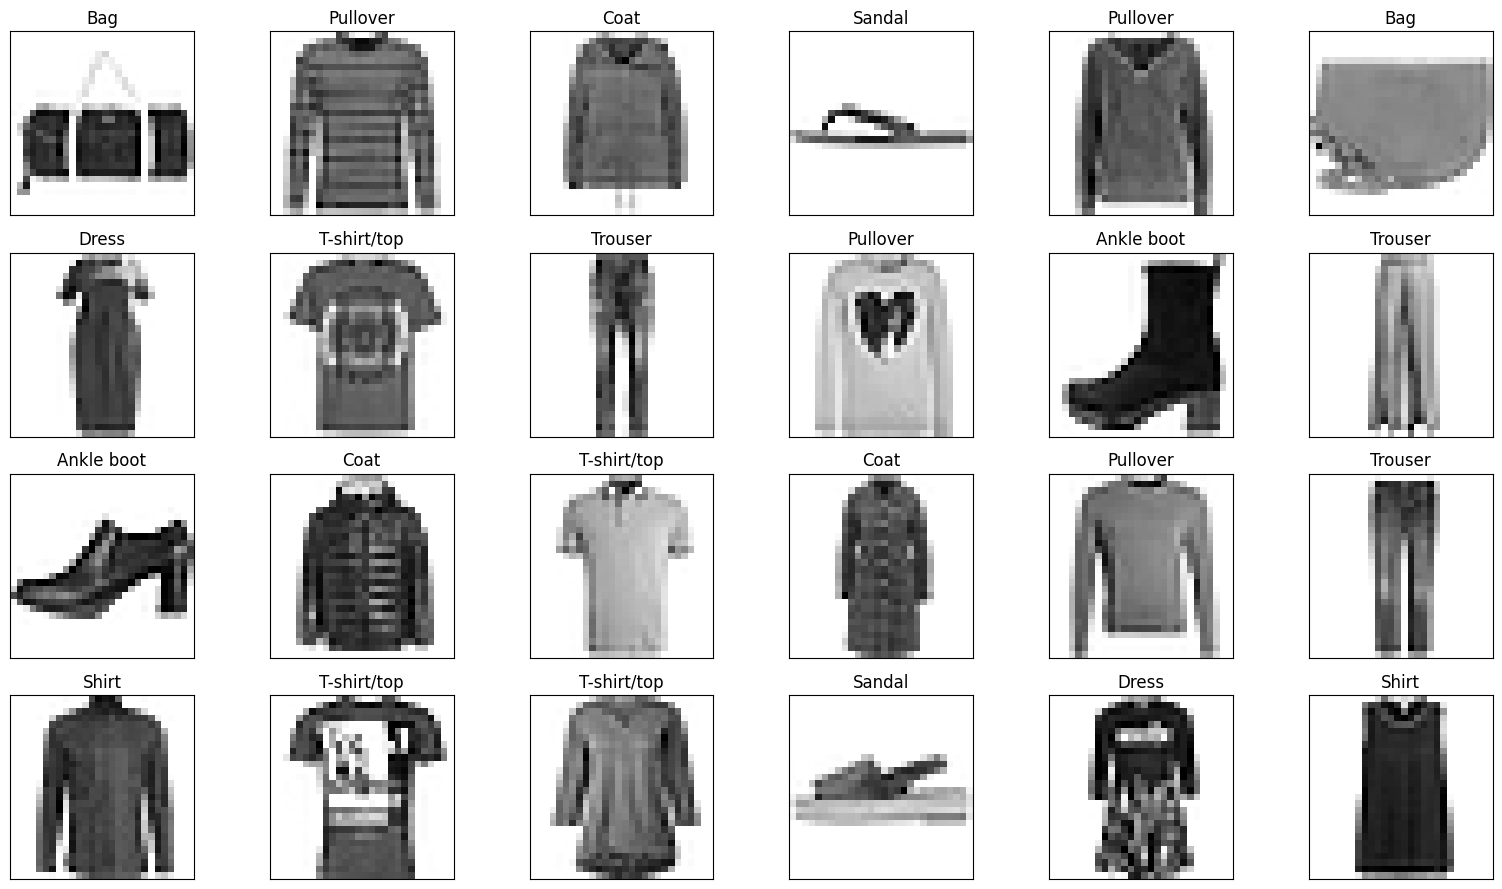

In [3]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

index = np.random.choice(np.arange(len(X_train)), 24, replace=False)
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for item in zip(axes.ravel(), X_train[index], y_train[index]):
    ax, image, target = item
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])  # remove x-axis tick marks
    ax.set_yticks([])  # remove y-axis tick marks
    ax.set_title(class_names[target])
plt.tight_layout()
plt.show()

In [4]:
from tensorflow.keras.utils import to_categorical

# Reshape to (samples, width, height, channels)
X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))

# Normalize pixel values to 0.0-1.0
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("y_train[0]:", y_train[0])

X_train: (60000, 28, 28, 1) y_train: (60000, 10)
X_test: (10000, 28, 28, 1) y_test: (10000, 10)
y_train[0]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

cnn = Sequential()
cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu",
               input_shape=(28, 28, 1)))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dense(units=128, activation="relu"))
cnn.add(Dense(units=10, activation="softmax"))

cnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
cnn.compile(optimizer="adam",
            loss="categorical_crossentropy",
            metrics=["accuracy"])

start = time.time()
cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
fashion_train_time = time.time() - start

print(f"\nFashion-MNIST training time: {fashion_train_time:.1f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8304 - loss: 0.4645 - val_accuracy: 0.8667 - val_loss: 0.3800
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8879 - loss: 0.3054 - val_accuracy: 0.8805 - val_loss: 0.3338
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9059 - loss: 0.2546 - val_accuracy: 0.8950 - val_loss: 0.2930
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9198 - loss: 0.2190 - val_accuracy: 0.9063 - val_loss: 0.2650
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9301 - loss: 0.1886 - val_accuracy: 0.9118 - val_loss: 0.2600

Fashion-MNIST training time: 26.3 seconds


In [7]:
loss, accuracy = cnn.evaluate(X_test, y_test)

start = time.time()
predictions = cnn.predict(X_test)
fashion_predict_time = time.time() - start

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.2%}")
print(f"Prediction time (10,000 images): {fashion_predict_time:.2f} seconds")

# Save the results for the comparison table at the end
results = [{
    "Experiment": "Fashion-MNIST (original model)",
    "Parameters": cnn.count_params(),
    "Test accuracy (%)": round(accuracy * 100, 2),
    "Training time (s)": round(fashion_train_time, 1),
    "Prediction time (s)": round(fashion_predict_time, 2),
}]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9071 - loss: 0.2827
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test loss: 0.2827
Test accuracy: 90.71%
Prediction time (10,000 images): 2.65 seconds


In [8]:
print("Expected:", class_names[np.argmax(y_test[0])])
for index, probability in enumerate(predictions[0]):
    print(f"{class_names[index]}: {probability:.10%}")

Expected: Ankle boot
T-shirt/top: 0.0000003859%
Trouser: 0.0000000469%
Pullover: 0.0000002052%
Dress: 0.0000000451%
Coat: 0.0000000171%
Sandal: 0.0006555030%
Shirt: 0.0000000179%
Sneaker: 0.0013822159%
Bag: 0.0000534785%
Ankle boot: 99.9979138374%


Number of incorrect predictions: 929 / 10000


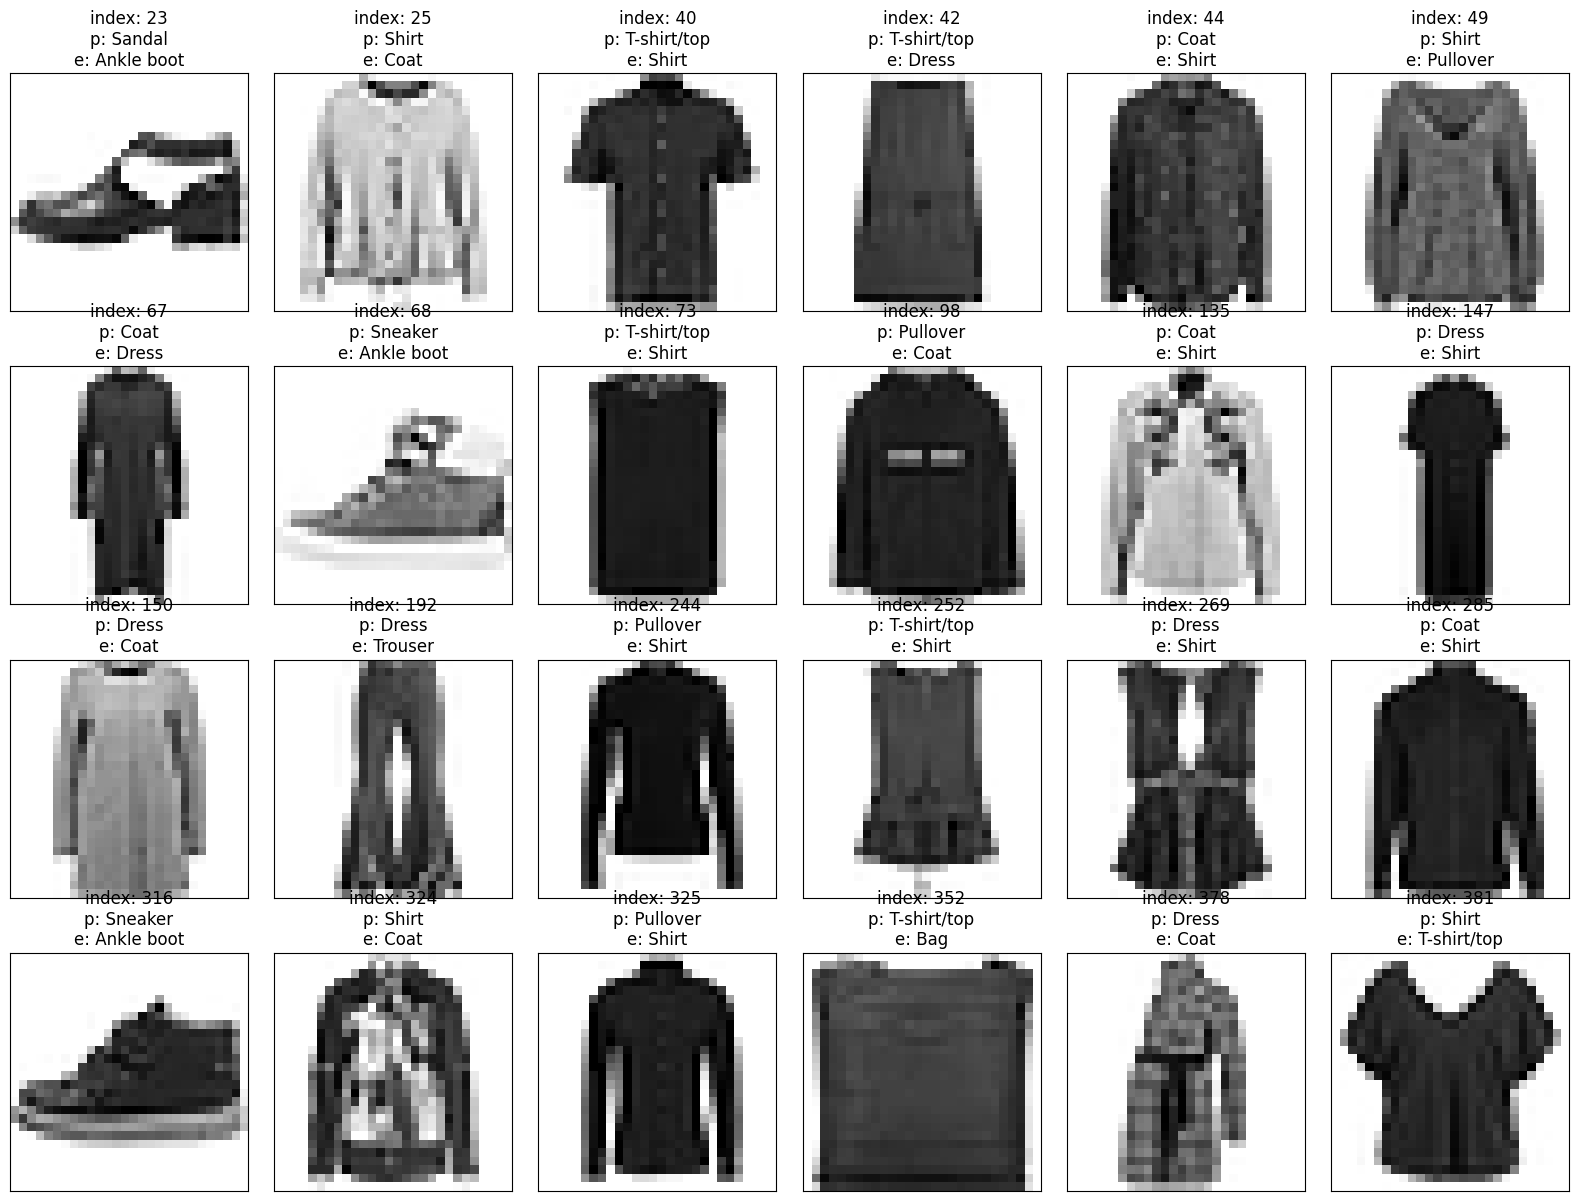

In [9]:
images = X_test.reshape((10000, 28, 28))
incorrect_predictions = []

for i, (p, e) in enumerate(zip(predictions, y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)
    if predicted != expected:
        incorrect_predictions.append((i, images[i], predicted, expected))

print("Number of incorrect predictions:", len(incorrect_predictions), "/ 10000")

figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 12))
for ax, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"index: {index}\np: {class_names[predicted]}\ne: {class_names[expected]}")
plt.tight_layout()
plt.show()

### Comparison with MNIST
To compare fairly, the same convnet is trained on MNIST with the same settings (5 epochs, batch size 64, validation split 0.1).

In [10]:
def create_cnn(variant="original"):
    """
    original      : the chapter's model (Flatten -> Dense 128 -> Dense 10)
    no_first_dense: first Dense layer removed (Flatten -> Dense 10)
    add_dense4096 : Dense 4096 added before the two Dense layers
                    (Flatten -> Dense 4096 -> Dense 128 -> Dense 10)
    """
    model = Sequential()
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation="relu",
                     input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    if variant == "add_dense4096":
        model.add(Dense(units=4096, activation="relu"))
    if variant in ("original", "add_dense4096"):
        model.add(Dense(units=128, activation="relu"))
    model.add(Dense(units=10, activation="softmax"))
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def train_and_evaluate(name, variant, X_train, y_train, X_test, y_test):
    keras.utils.set_random_seed(42)
    model = create_cnn(variant)

    start = time.time()
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
    train_time = time.time() - start

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    start = time.time()
    model.predict(X_test, verbose=0)
    predict_time = time.time() - start

    results.append({
        "Experiment": name,
        "Parameters": model.count_params(),
        "Test accuracy (%)": round(accuracy * 100, 2),
        "Training time (s)": round(train_time, 1),
        "Prediction time (s)": round(predict_time, 2),
    })
    print(f"\n{name}: test accuracy = {accuracy:.2%}, "
          f"training time = {train_time:.1f}s, prediction time = {predict_time:.2f}s")
    return model

In [11]:
from tensorflow.keras.datasets import mnist

(X_train_m, y_train_m), (X_test_m, y_test_m) = mnist.load_data()
X_train_m = X_train_m.reshape((60000, 28, 28, 1)).astype("float32") / 255
X_test_m = X_test_m.reshape((10000, 28, 28, 1)).astype("float32") / 255
y_train_m = to_categorical(y_train_m)
y_test_m = to_categorical(y_test_m)

mnist_model = train_and_evaluate("MNIST (original model)", "original",
                                 X_train_m, y_train_m, X_test_m, y_test_m)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9574 - loss: 0.1373 - val_accuracy: 0.9832 - val_loss: 0.0612
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9868 - loss: 0.0412 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9919 - loss: 0.0262 - val_accuracy: 0.9820 - val_loss: 0.0640
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9880 - val_loss: 0.0464
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9949 - loss: 0.0146 - val_accuracy: 0.9887 - val_loss: 0.0439

MNIST (original model): test accuracy = 98.69%, training time = 25.0s, prediction time = 1.30s


## Exercise 16.4: Convnet Layers
Both experiments use Fashion-MNIST.
1. Remove the first `Dense` layer (the one with 128 neurons).
2. Add a `Dense` layer with 4096 neurons before the two `Dense` layers.

In [12]:
no_dense_model = train_and_evaluate("Fashion-MNIST (first Dense removed)", "no_first_dense",
                                    X_train, y_train, X_test, y_test)
no_dense_model.summary()

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8227 - loss: 0.4934 - val_accuracy: 0.8573 - val_loss: 0.4038
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8805 - loss: 0.3328 - val_accuracy: 0.8760 - val_loss: 0.3553
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8953 - loss: 0.2892 - val_accuracy: 0.8863 - val_loss: 0.3224
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9054 - loss: 0.2589 - val_accuracy: 0.8955 - val_loss: 0.2998
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9151 - loss: 0.2338 - val_accuracy: 0.9012 - val_loss: 0.2849

Fashion-MNIST (first Dense removed): test accuracy = 89.35%, training time = 23.9s, prediction time = 1.28s


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,520 (1.22 MB)

 Trainable params: 106,506 (416.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 213,014 (832.09 KB)

In [13]:
dense4096_model = train_and_evaluate("Fashion-MNIST (Dense 4096 added)", "add_dense4096",
                                     X_train, y_train, X_test, y_test)
dense4096_model.summary()

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8452 - loss: 0.4191 - val_accuracy: 0.8718 - val_loss: 0.3506
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8990 - loss: 0.2712 - val_accuracy: 0.8845 - val_loss: 0.3156
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9178 - loss: 0.2184 - val_accuracy: 0.8980 - val_loss: 0.2844
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9346 - loss: 0.1778 - val_accuracy: 0.8965 - val_loss: 0.3312
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9454 - loss: 0.1447 - val_accuracy: 0.9033 - val_loss: 0.3431

Fashion-MNIST (Dense 4096 added): test accuracy = 90.19%, training time = 37.8s, prediction time = 1.82s


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    13,111,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,134,496 (156.92 MB)

 Trainable params: 13,711,498 (52.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,422,998 (104.61 MB)

,Experiment,Parameters,Test accuracy (%),Training time (s),Prediction time (s)
0,Fashion-MNIST (original model),485514,90.71,26.3,2.65
1,MNIST (original model),485514,98.69,25.0,1.30
2,Fashion-MNIST (first Dense removed),106506,89.35,23.9,1.28
3,Fashion-MNIST (Dense 4096 added),13711498,90.19,37.8,1.82


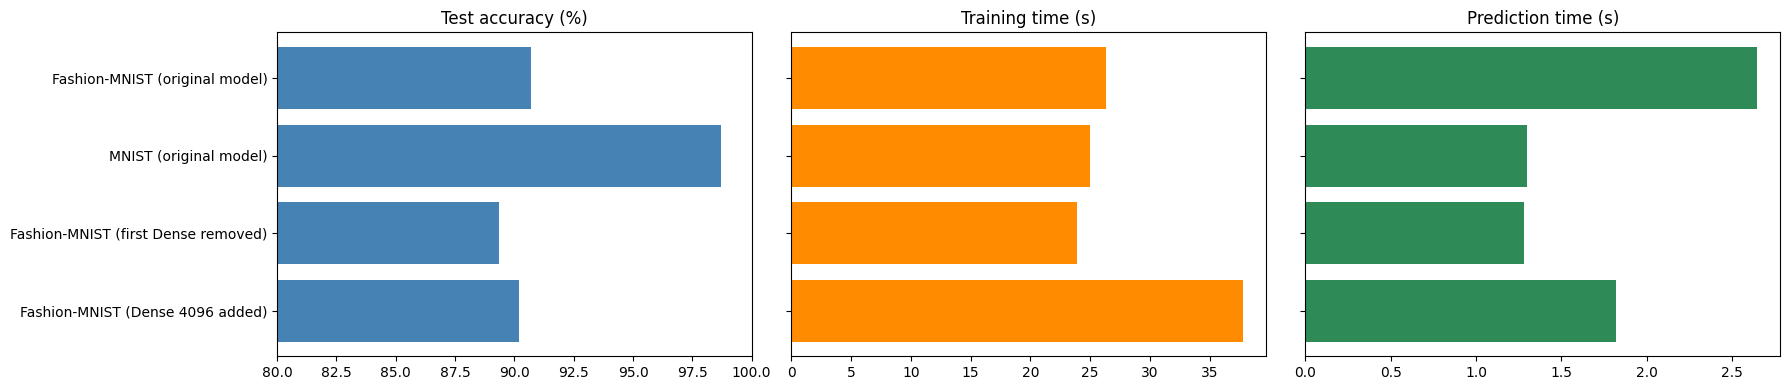

In [14]:
df = pd.DataFrame(results)
display(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].barh(df["Experiment"], df["Test accuracy (%)"], color="steelblue")
axes[0].set_xlim(80, 100)
axes[0].set_title("Test accuracy (%)")
axes[1].barh(df["Experiment"], df["Training time (s)"], color="darkorange")
axes[1].set_title("Training time (s)")
axes[2].barh(df["Experiment"], df["Prediction time (s)"], color="seagreen")
axes[2].set_title("Prediction time (s)")
for ax in axes:
    ax.invert_yaxis()
for ax in axes[1:]:
    ax.set_yticklabels([])
plt.tight_layout()
plt.show()

## Answers

### Exercise 16.1: How well does the model perform on Fashion-MNIST compared to MNIST? How do the training times compare?

| Dataset | Test accuracy | Incorrect predictions | Training time |
|---|---|---|---|
| MNIST | 98.69% | about 131 / 10,000 | 25.0 s |
| Fashion-MNIST | 90.71% | 929 / 10,000 | 26.3 s |

- **Accuracy:** The same convnet reached **98.69%** test accuracy on MNIST (close to the book's 99.17%) but only **90.71%** on Fashion-MNIST, about 8 percentage points lower. On Fashion-MNIST the model made **929** incorrect predictions out of 10,000, compared with only 83 in the book's MNIST model.
- **Why Fashion-MNIST is harder:** Many clothing classes look very similar in small 28x28 grayscale images. The incorrect predictions in the incorrect predictions shown above show typical confusions: a Coat predicted as a Shirt, a Shirt predicted as a T-shirt/top, a Dress predicted as a T-shirt/top, and an Ankle boot predicted as a Sandal. Handwritten digits have more distinct shapes, so they are easier to classify.
- **Training time:** Training took **25.0 s** on MNIST and **26.3 s** on Fashion-MNIST on a Tesla T4 GPU, which is almost the same. Both datasets have the same number of images (60,000 training, 10,000 testing), the same image size (28x28x1) and the same model with 485,514 parameters, so the amount of computation is identical. The small difference is just normal timing variation.

### Exercise 16.4: How do the Dense layer changes affect prediction accuracy and speed? (Fashion-MNIST)

| Model | Parameters | Test accuracy | Training time | Prediction time |
|---|---|---|---|---|
| Original (Dense 128 + Dense 10) | 485,514 | 90.71% | 26.3 s | 2.65 s* |
| First Dense layer removed | 106,506 | 89.35% | 23.9 s | 1.28 s |
| Dense 4096 added | 13,711,498 | 90.19% | 37.8 s | 1.82 s |

\* The original model's prediction time includes one-time start-up overhead, because it was the first prediction run in the notebook. The MNIST model, which has the same architecture, needed only 1.30 s, which is a fairer value to compare.

- **Removing the first Dense layer:** The number of parameters dropped by about 78% (from 485,514 to 106,506), and training became slightly faster (23.9 s vs. 26.3 s). Accuracy decreased a little, from **90.71% to 89.35%**. The convolution and pooling layers still learn the image features, but without the Dense 128 layer the model has less ability to learn the relationships among those features before classifying them.
- **Adding a Dense layer with 4096 neurons:** The model grew to **13.7 million parameters**, about 28 times more than the original. Training took about 44% longer (**37.8 s vs. 26.3 s**), and prediction was also slower (1.82 s vs. about 1.30 s). However, accuracy did not improve; it was slightly lower (**90.19% vs. 90.71%**), likely because such a large layer starts to overfit the training data. As the book explains, Dense layers with 4096 neurons are used in convnets for large, high-resolution datasets like ImageNet. For small 28x28 images, the extra layer only makes the model bigger and slower. This is confirmed by the training output: in the last epoch the training accuracy was 94.54% but the validation accuracy was only 90.33%, and the validation loss increased from 0.3312 to 0.3431, which are signs of overfitting.

### Conclusion
The chapter's original convnet gives the best balance of accuracy and speed for Fashion-MNIST. Removing the Dense layer makes the model smaller but slightly less accurate, while adding a 4096-neuron layer makes it much larger and slower without improving accuracy.